[Previous: GoF 3: Structural Patterns, Part 2](03_Structural_Part_2.ipynb)  |  [Course Index](../00_Start_Here.ipynb)  |  [Next: GoF 5: Behavioral Patterns, Part 2](05_Behavioral_Part_2.ipynb)

# GoF 4: Behavioral Patterns, Part 1

Behavioral patterns are about **how objects communicate and share responsibility**.

**Learning objectives.** After this module you can:

* route a request through a Chain of Responsibility and explain why the sender does not know the receiver;
* turn operations into Command objects to get undo, redo, queues and macros;
* implement the Iterator protocol by hand and with generators;
* untangle many-to-many communication with a Mediator.

## 1. Chain of Responsibility

**Problem.** A support ticket might be answered by a bot, a first-line agent, a specialist or a manager, depending on its content. The sender should not decide who.

**Structure.** Each handler holds a reference to the next. A handler either handles the request or passes it on. The chain is assembled once; the client sends to its head.

'I forgot my password'           -> Bot: use the reset link
'the app crashes on start'       -> Specialist: patch scheduled
'cancel my subscription'         -> no one could handle this


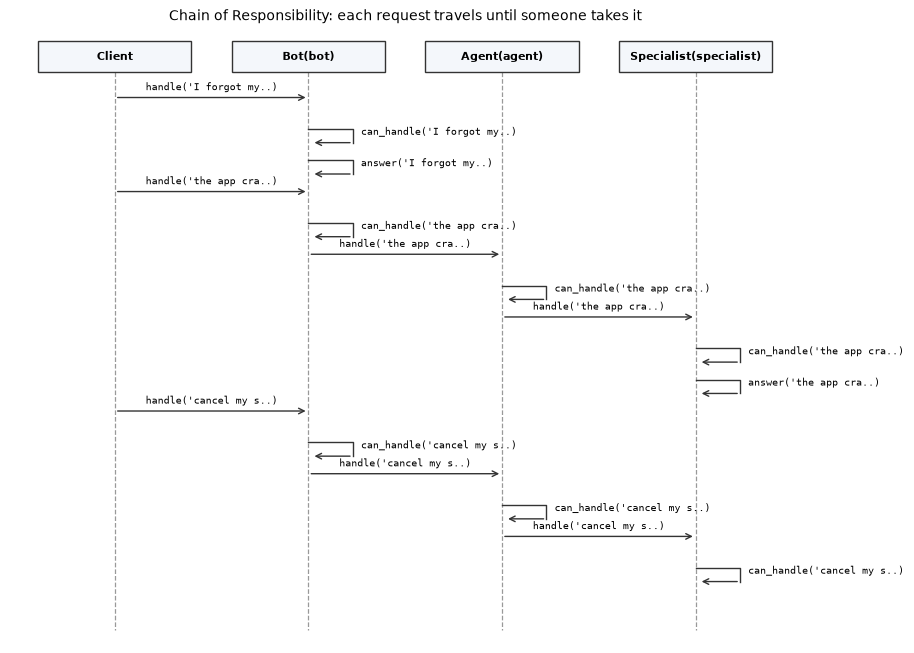

In [1]:
from dplab import class_diagram, traced, trace

@traced
class Handler:
    def __init__(self, next_handler=None):
        self.next = next_handler

    def handle(self, ticket):
        if self.can_handle(ticket):
            return self.answer(ticket)
        if self.next:
            return self.next.handle(ticket)
        return "no one could handle this"

    def can_handle(self, ticket):
        return False

@traced
class Bot(Handler):
    name = "bot"
    def can_handle(self, ticket): return "password" in ticket
    def answer(self, ticket):     return "Bot: use the reset link"

@traced
class Agent(Handler):
    name = "agent"
    def can_handle(self, ticket): return "invoice" in ticket or "refund" in ticket
    def answer(self, ticket):     return "Agent: I have sent a corrected invoice"

@traced
class Specialist(Handler):
    name = "specialist"
    def can_handle(self, ticket): return "crash" in ticket
    def answer(self, ticket):     return "Specialist: patch scheduled"

chain = Bot(Agent(Specialist()))
with trace() as t:
    for ticket in ["I forgot my password", "the app crashes on start", "cancel my subscription"]:
        print(f"{ticket!r:<32} -> {chain.handle(ticket)}")
t.diagram(title="Chain of Responsibility: each request travels until someone takes it", max_messages=24)

### Lab: Chain of Responsibility Lab

Purchase approvals with spending limits. Move the amount and the limits; watch which approver takes it and who passes it on.

Chain of Responsibility Lab (static preview). Run this cell in JupyterLab for the interactive version.


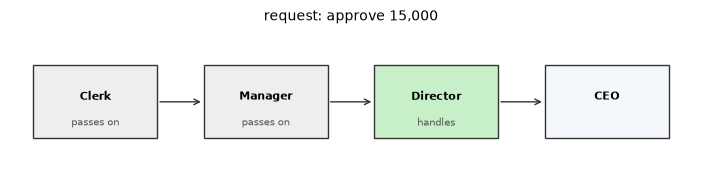

In [2]:
from dplab import chain_lab

chain_lab()

## 2. Command

**Problem.** Operations need to be undone, queued, logged or replayed. A method call vanishes the moment it returns; an object can be kept.

**Structure.** Each operation becomes an object with `execute()` and `undo()` that carries everything it needs. An invoker keeps a history. A macro command holds a list of commands.

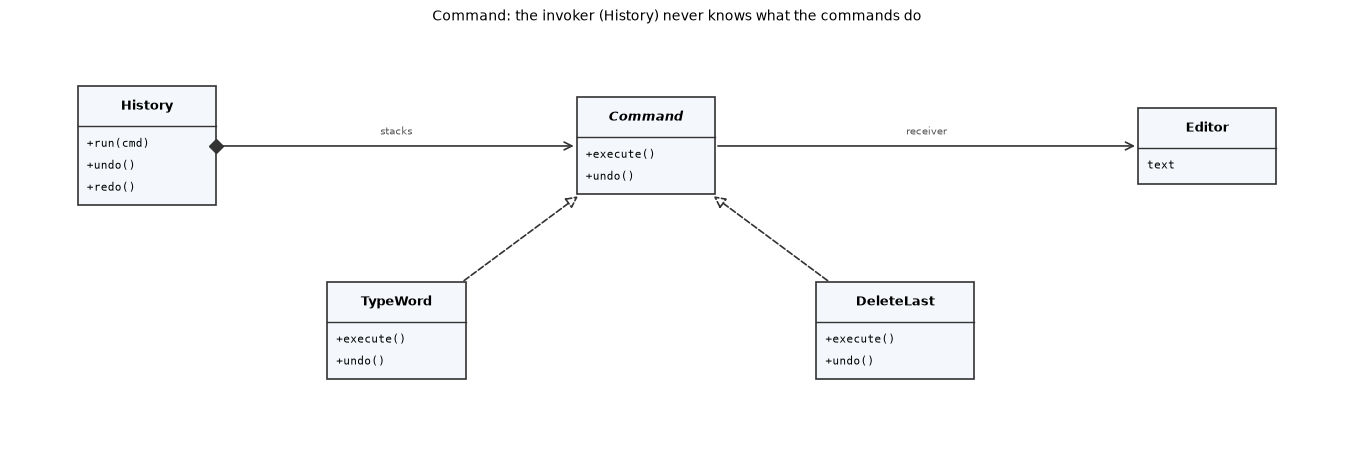

In [3]:
class_diagram(
    {"Command": ["+execute()", "+undo()"], "TypeWord": ["+execute()", "+undo()"], "DeleteLast": ["+execute()", "+undo()"],
     "History": ["+run(cmd)", "+undo()", "+redo()"], "Editor": ["text"]},
    [("TypeWord", "Command", "implements"), ("DeleteLast", "Command", "implements"), ("History", "Command", "has", "stacks"), ("Command", "Editor", "refers", "receiver")],
    abstract={"Command"}, layout={"History": (-1.6, 0), "Command": (0, 0), "Editor": (1.8, 0), "TypeWord": (-0.8, 1), "DeleteLast": (0.8, 1)},
    title="Command: the invoker (History) never knows what the commands do")

In [4]:
class Editor:
    def __init__(self):
        self.text = ""

class Command:
    def __init__(self, editor):
        self.editor, self.before = editor, editor.text
    def undo(self):
        self.editor.text = self.before                 # the simplest undo: restore the snapshot

class TypeWord(Command):
    def __init__(self, editor, word):
        super().__init__(editor); self.word = word
    def execute(self):
        self.editor.text = (self.editor.text + " " + self.word).strip()

class DeleteLast(Command):
    def execute(self):
        self.editor.text = " ".join(self.editor.text.split()[:-1])

class Macro:
    def __init__(self, commands): self.commands = commands
    def execute(self):
        for c in self.commands: c.execute()
    def undo(self):
        for c in reversed(self.commands): c.undo()

class History:
    def __init__(self): self.undo_stack, self.redo_stack = [], []
    def run(self, cmd):
        cmd.execute(); self.undo_stack.append(cmd); self.redo_stack.clear()
    def undo(self):
        if self.undo_stack:
            cmd = self.undo_stack.pop(); cmd.undo(); self.redo_stack.append(cmd)
    def redo(self):
        if self.redo_stack:
            cmd = self.redo_stack.pop(); cmd.execute(); self.undo_stack.append(cmd)

ed, hist = Editor(), History()
hist.run(TypeWord(ed, "design"))
hist.run(Macro([TypeWord(ed, "patterns"), TypeWord(ed, "everywhere"), DeleteLast(ed)]))
print("after macro:", repr(ed.text))
hist.undo();  print("undo macro: ", repr(ed.text))
hist.redo();  print("redo macro: ", repr(ed.text))

after macro: 'design patterns'
undo macro:  'design'
redo macro:  'design patterns'


### Lab: Command Lab

Type words, transform the text, then undo and redo while watching the two stacks.

Command Lab (static preview). Run this cell in JupyterLab for the interactive version.


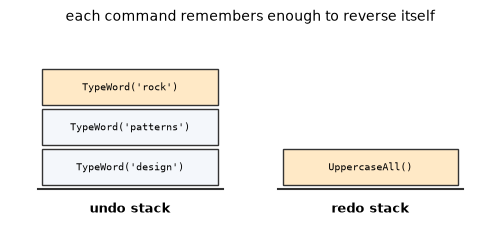

In [5]:
from dplab import command_lab

command_lab()

## 3. Iterator

**Problem.** Walk through the elements of a collection without exposing how it stores them, and without the collection having to know what you do with each element.

**Structure.** Python bakes the pattern into the language: `__iter__` returns an iterator, `__next__` produces the next item or raises `StopIteration`. Generators write the iterator for you.

In [6]:
class Countdown:
    def __init__(self, start): self.start = start
    def __iter__(self):                       # returns a fresh iterator each time
        return CountdownIterator(self.start)

class CountdownIterator:
    def __init__(self, current): self.current = current
    def __iter__(self): return self
    def __next__(self):
        if self.current <= 0:
            raise StopIteration
        self.current -= 1
        return self.current + 1

print("by hand:  ", list(Countdown(5)))

def countdown(start):                          # the same thing as a generator: the frame IS the iterator state
    while start > 0:
        yield start
        start -= 1

print("generator:", list(countdown(5)))

# A less trivial iterator: depth-first walk over the Composite tree from Module 2, as a generator.
class Node:
    def __init__(self, name, *children): self.name, self.children = name, list(children)
    def __iter__(self):
        yield self.name
        for child in self.children:
            yield from child                   # recursion through the iterator protocol

tree = Node("root", Node("a", Node("a1"), Node("a2")), Node("b"))
print("tree walk: ", list(tree))
print("works with any consumer:", [n.upper() for n in tree if n.startswith("a")])

by hand:   [5, 4, 3, 2, 1]
generator: [5, 4, 3, 2, 1]
tree walk:  ['root', 'a', 'a1', 'a2', 'b']
works with any consumer: ['A', 'A1', 'A2']


## 4. Mediator

**Problem.** A form has a checkbox, a text field and a button, and each must react to the others: enable the field when the box is ticked, enable the button when the field is non-empty. Wiring every widget to every other widget is n-squared coupling.

**Structure.** Components report events to one mediator; the mediator holds the coordination logic and tells components what to do. Components know only the mediator.

button enabled: True


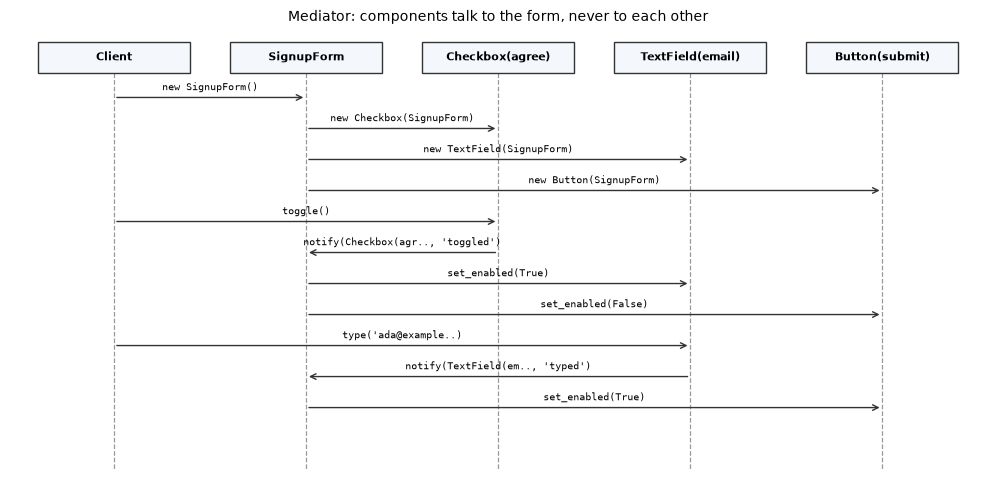

In [7]:
@traced
class Checkbox:
    name = "agree"
    def __init__(self, mediator): self.mediator, self.checked = mediator, False
    def toggle(self):
        self.checked = not self.checked
        self.mediator.notify(self, "toggled")

@traced
class TextField:
    name = "email"
    def __init__(self, mediator): self.mediator, self.text, self.enabled = mediator, "", False
    def type(self, text):
        self.text = text
        self.mediator.notify(self, "typed")
    def set_enabled(self, on): self.enabled = on

@traced
class Button:
    name = "submit"
    def __init__(self, mediator): self.mediator, self.enabled = mediator, False
    def set_enabled(self, on): self.enabled = on

@traced
class SignupForm:                                  # the mediator: all the rules live here
    def __init__(self):
        self.box, self.field, self.button = Checkbox(self), TextField(self), Button(self)

    def notify(self, sender, event):
        if sender is self.box and event == "toggled":
            self.field.set_enabled(self.box.checked)
            self.button.set_enabled(False)
        elif sender is self.field and event == "typed":
            self.button.set_enabled("@" in self.field.text and self.box.checked)

with trace() as t:
    form = SignupForm()
    form.box.toggle()
    form.field.type("ada@example.com")
print("button enabled:", form.button.enabled)
t.diagram(title="Mediator: components talk to the form, never to each other")

> **What to notice.** Neither the checkbox nor the field knows the button exists. Add a fourth widget and only the mediator changes.

## Try it yourself

**Exercise 1.** Add a `Manager` handler at the end of the support chain that handles anything containing "complaint", and reorder the chain so the bot comes last. Does the output change?

**Exercise 2.** Make `TypeWord.undo` precise instead of snapshot-based: remove exactly the word it added. When would the snapshot approach be wrong?

**Exercise 3.** Write a generator `pairs(iterable)` that yields consecutive pairs `(a, b), (b, c), ...` and use it to detect repeated words in a sentence.

**Exercise 4 (challenge).** Turn the `SignupForm` mediator into an Observer-style event bus (`on(event, handler)`) and compare: which one keeps the rules in one readable place?

<details><summary>Solutions</summary>

```python
# Exercise 1: order matters only when two handlers could both handle a ticket; here the sets are disjoint, so the output is the same.

# Exercise 2
def precise_undo(self):
    words = self.editor.text.split()
    if words and words[-1] == self.word: self.editor.text = " ".join(words[:-1])
TypeWord.undo = precise_undo
# The snapshot is wrong if something else changed the editor between execute and undo; precise undo is wrong if a later command changed the last word.

# Exercise 3
def pairs(it):
    it = iter(it); prev = next(it)
    for x in it:
        yield prev, x; prev = x
print([a for a, b in pairs("the the cat sat sat".split()) if a == b])

# Exercise 4: the event bus spreads the rules over many small handlers; the mediator keeps them in one notify(). Mediator wins when the rules interact.
```

</details>

## Checkpoint quiz

Four quick questions. Answer them before reading the takeaways. If you miss one, the explanation points you to the section to re-read.

In [8]:
from dplab import quiz

quiz(4)

Checkpoint quiz, Module 4 (static preview). Run this cell in JupyterLab to answer interactively.

Q1. Chain of Responsibility
    a) broadcasts a request to all handlers
    b) passes a request along handlers until one handles it
    c) stores requests for undo
    d) iterates a collection

Q2. Turning a request into a Command object makes it possible to
    a) run it faster
    b) queue, log and undo it
    c) avoid classes
    d) share state

Q3. Python generators are a built-in form of
    a) Iterator
    b) Mediator
    c) Command
    d) Facade

Q4. Mediator exists to
    a) replace many-to-many links between components with one hub
    b) create objects
    c) wrap objects
    d) store snapshots


## Key takeaways

* Chain of Responsibility: handlers in a line, each handles or passes on; the sender never chooses.
* Command: operations as objects, which is what makes undo, redo, macros and queues possible.
* Iterator is built into Python; generators are the shortest way to write one.
* Mediator collects the coordination logic in one object so components stay ignorant of each other.

**Next:** Observer, State, Strategy and Memento. [GoF 5](05_Behavioral_Part_2.ipynb).

[Previous: GoF 3: Structural Patterns, Part 2](03_Structural_Part_2.ipynb)  |  [Course Index](../00_Start_Here.ipynb)  |  [Next: GoF 5: Behavioral Patterns, Part 2](05_Behavioral_Part_2.ipynb)